In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("richave/tortilla-prices-in-mexico")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\noefp\.cache\kagglehub\datasets\richave\tortilla-prices-in-mexico\versions\7


--- D. CONSISTENCIA POR CIUDADES ---


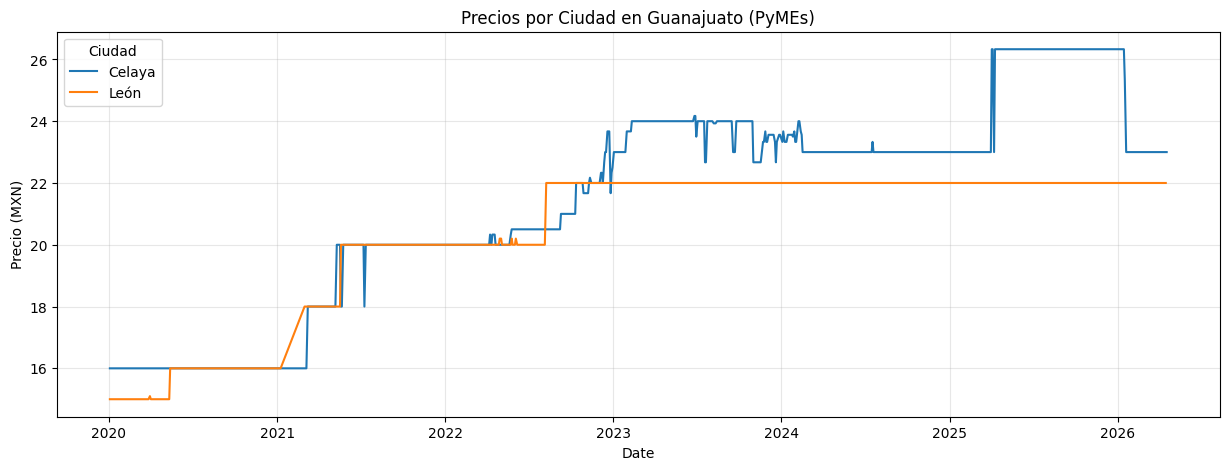


--- A. ANÁLISIS DE HUECOS CRÍTICOS ---
Total de días faltantes (NaNs): 1405
El hueco continuo más grande es de: 67 días.
⚠️ ADVERTENCIA: Hay un hueco mayor a 15 días. La interpolación podría generar datos de baja fidelidad en ese tramo.

--- B. ANÁLISIS DE VALORES ATÍPICOS ---
Outliers detectados (errores de captura): 0

--- C. PRUEBA DE ESTACIONARIEDAD (Dicker-Fuller) ---
P-Valor: 0.32013
🚨 Conclusión: La serie NO es estacionaria (tiene una fuerte tendencia al alza).
👉 ACCIÓN OBLIGATORIA: Debes escalar los datos con MinMaxScaler antes de pasarlos a la LSTM.


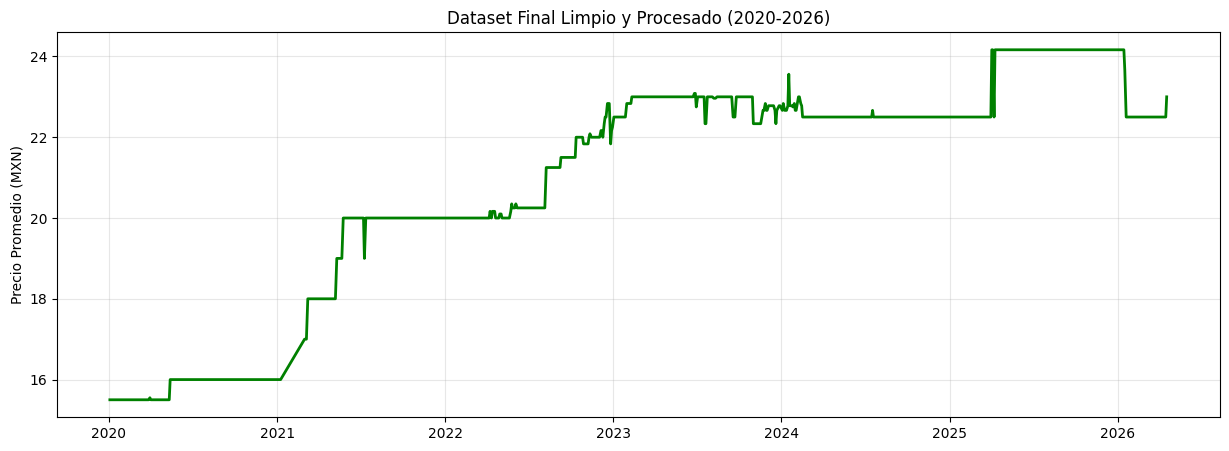


Datos listos: 2297 filas continuas para alimentar el modelo.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from statsmodels.tsa.stattools import adfuller

# =====================================================================
# 1. CARGA Y FILTRADO INICIAL (Años 2020+ y PyMEs en Guanajuato)
# =====================================================================
path = kagglehub.dataset_download("richave/tortilla-prices-in-mexico")
files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, files[0]))

df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Filtramos: Solo Guanajuato, solo Tiendas Locales, y desde el año 2020
df_pyme = df[(df['State'] == 'Guanajuato') & 
             (df['Store type'] == 'Mom and Pop Store') & 
             (df['Date'] >= '2020-01-01')].copy()

# =====================================================================
# D. CONSISTENCIA POR CIUDADES (Análisis de Mercados Locales)
# =====================================================================
print("--- D. CONSISTENCIA POR CIUDADES ---")
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_pyme, x='Date', y='Price per kilogram', hue='City')
plt.title('Precios por Ciudad en Guanajuato (PyMEs)')
plt.ylabel('Precio (MXN)')
plt.legend(title='Ciudad')
plt.grid(True, alpha=0.3)
plt.show()

# Agrupamos por fecha para obtener la serie del Estado
df_daily = df_pyme.groupby('Date')['Price per kilogram'].mean().reset_index()
df_daily.set_index('Date', inplace=True)
df_daily = df_daily.asfreq('D')

# =====================================================================
# A. DETECCIÓN DE HUECOS CRÍTICOS (Gap Check)
# =====================================================================
print("\n--- A. ANÁLISIS DE HUECOS CRÍTICOS ---")
nans_boolean = df_daily['Price per kilogram'].isna()

# Magia de Pandas para contar el tamaño del bloque de NaNs consecutivos
grupos_nans = nans_boolean.groupby((~nans_boolean).cumsum())
max_gap = grupos_nans.sum().max()

print(f"Total de días faltantes (NaNs): {nans_boolean.sum()}")
print(f"El hueco continuo más grande es de: {int(max_gap)} días.")

if max_gap > 15:
    print("⚠️ ADVERTENCIA: Hay un hueco mayor a 15 días. La interpolación podría generar datos de baja fidelidad en ese tramo.")
else:
    print("✅ Los huecos son pequeños, la interpolación es segura.")

# =====================================================================
# B. ANÁLISIS DE OUTLIERS (Rango Intercuartílico - IQR Móvil)
# =====================================================================
print("\n--- B. ANÁLISIS DE VALORES ATÍPICOS ---")
# Usamos un promedio móvil de 30 días para no castigar la inflación real
rolling_median = df_daily['Price per kilogram'].rolling(window=30, min_periods=1, center=False).median()
error_abs = np.abs(df_daily['Price per kilogram'] - rolling_median)

# Asumimos que un salto de más de 3 pesos en un solo día respecto al promedio del mes es un error
umbral_error = 3.0 
outliers_mask = error_abs > umbral_error

print(f"Outliers detectados (errores de captura): {outliers_mask.sum()}")
# Reemplazamos los outliers con NaN para que sean limpiados por la interpolación
df_daily.loc[outliers_mask, 'Price per kilogram'] = np.nan

# --- AHORA SÍ APLICAMOS LA INTERPOLACIÓN ---
df_daily['Price per kilogram'] = df_daily['Price per kilogram'].interpolate(method='time')
df_daily['Price per kilogram'] = df_daily['Price per kilogram'].bfill().ffill()

# =====================================================================
# C. PRUEBA DE ESTACIONARIEDAD (ADF Test)
# =====================================================================
print("\n--- C. PRUEBA DE ESTACIONARIEDAD (Dicker-Fuller) ---")
adf_result = adfuller(df_daily['Price per kilogram'])
p_value = adf_result[1]

print(f"P-Valor: {p_value:.5f}")
if p_value > 0.05:
    print("🚨 Conclusión: La serie NO es estacionaria (tiene una fuerte tendencia al alza).")
    print("👉 ACCIÓN OBLIGATORIA: Debes escalar los datos con MinMaxScaler antes de pasarlos a la LSTM.")
else:
    print("✅ Conclusión: La serie es estacionaria.")

# =====================================================================
# VISUALIZACIÓN FINAL
# =====================================================================
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['Price per kilogram'], color='green', linewidth=2)
plt.title('Dataset Final Limpio y Procesado (2020-2026)')
plt.ylabel('Precio Promedio (MXN)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nDatos listos: {len(df_daily)} filas continuas para alimentar el modelo.")

🚀 Entrenando modelo optimizado en: cuda

--- INICIANDO ENTRENAMIENTO ---
Época [1/50] | Train Loss: 0.203535 | Val Loss: 0.045407
Época [2/50] | Train Loss: 0.021633 | Val Loss: 0.001045
Época [3/50] | Train Loss: 0.011940 | Val Loss: 0.004705
Época [4/50] | Train Loss: 0.008166 | Val Loss: 0.005413
Época [5/50] | Train Loss: 0.006689 | Val Loss: 0.005491
Época [6/50] | Train Loss: 0.006434 | Val Loss: 0.007250
Época [7/50] | Train Loss: 0.005754 | Val Loss: 0.008148
Época [8/50] | Train Loss: 0.005050 | Val Loss: 0.006266
Época [9/50] | Train Loss: 0.004753 | Val Loss: 0.000930
Época [10/50] | Train Loss: 0.004532 | Val Loss: 0.002882
Época [11/50] | Train Loss: 0.004603 | Val Loss: 0.002123
Época [12/50] | Train Loss: 0.004097 | Val Loss: 0.000680
Época [13/50] | Train Loss: 0.003674 | Val Loss: 0.002096
Época [14/50] | Train Loss: 0.004270 | Val Loss: 0.000690
Época [15/50] | Train Loss: 0.003902 | Val Loss: 0.003815
Época [16/50] | Train Loss: 0.003682 | Val Loss: 0.000909
Época [1

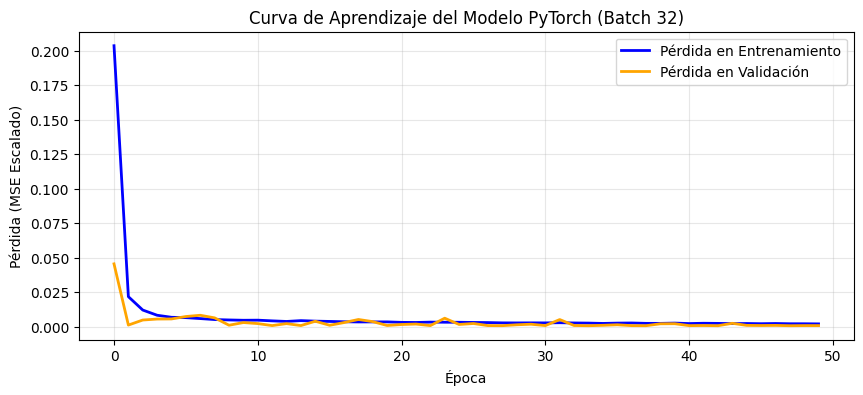

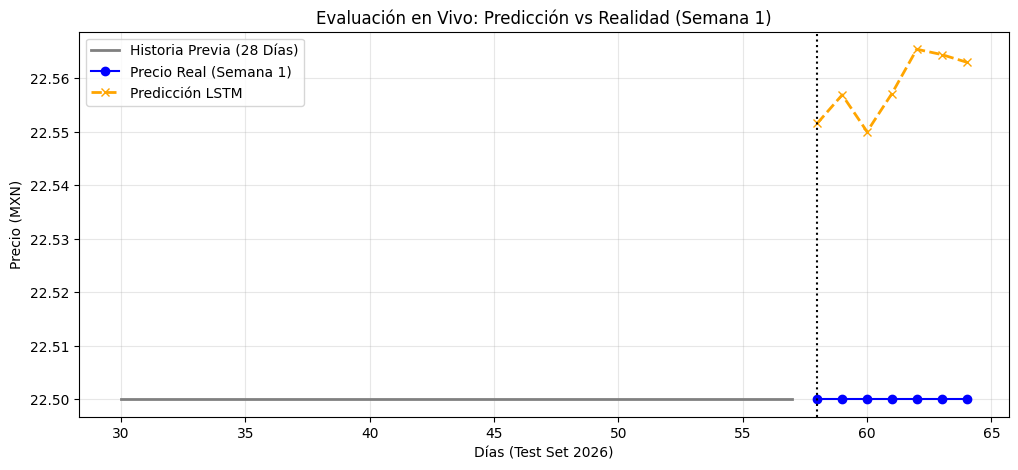

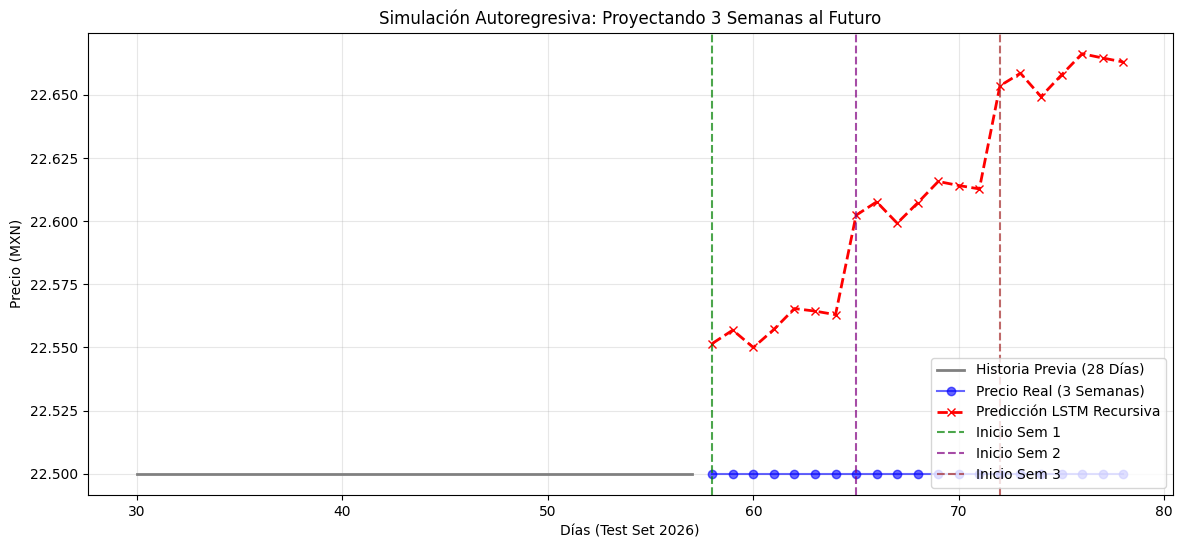

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import copy # Importamos copy para guardar el mejor modelo en RAM

# =====================================================================
# 0. CONFIGURACIÓN OPTIMIZADA Y PARÁMETROS
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Entrenando modelo optimizado en: {device}")

LOOK_BACK = 28           # 4 semanas continuas
FORECAST_HORIZON = 7     # Proyectar 1 semana completa
EPOCHS = 50              
BATCH_SIZE = 32          # Estabiliza la curva de aprendizaje
LEARNING_RATE = 0.001    

# =====================================================================
# 1. DIVISIÓN Y ESCALADO DE DATOS (MinMaxScaler)
# =====================================================================
train_df = df_daily[(df_daily.index >= '2020-01-01') & (df_daily.index <= '2024-12-31')]
val_df = df_daily[(df_daily.index >= '2025-01-01') & (df_daily.index <= '2025-12-31')]
test_df = df_daily[df_daily.index >= '2026-01-01']

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['Price per kilogram']])
val_scaled = scaler.transform(val_df[['Price per kilogram']])
test_scaled = scaler.transform(test_df[['Price per kilogram']])

# =====================================================================
# 2. CREACIÓN DE VENTANAS MULTI-PASO
# =====================================================================
def create_dataset(data, look_back, forecast):
    X, Y = [], []
    for i in range(len(data) - look_back - forecast + 1):
        X.append(data[i : (i + look_back), 0])
        Y.append(data[(i + look_back) : (i + look_back + forecast), 0])
    return np.array(X), np.array(Y)

X_train_np, Y_train_np = create_dataset(train_scaled, LOOK_BACK, FORECAST_HORIZON)
X_val_np, Y_val_np = create_dataset(val_scaled, LOOK_BACK, FORECAST_HORIZON)
X_test_np, Y_test_np = create_dataset(test_scaled, LOOK_BACK, FORECAST_HORIZON)

# --- CONVERSIÓN A TENSORES ---
X_train_t = torch.FloatTensor(X_train_np).unsqueeze(-1).to(device)
Y_train_t = torch.FloatTensor(Y_train_np).to(device)

X_val_t = torch.FloatTensor(X_val_np).unsqueeze(-1).to(device)
Y_val_t = torch.FloatTensor(Y_val_np).to(device)

X_test_t = torch.FloatTensor(X_test_np).unsqueeze(-1).to(device)
Y_test_t = torch.FloatTensor(Y_test_np).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=BATCH_SIZE, shuffle=False)

# =====================================================================
# 3. ARQUITECTURA DEL MODELO (Con Regularización)
# =====================================================================
class PymeLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=7):
        super(PymeLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] 
        out = self.dropout(out)
        out = self.fc(out)
        return out

model = PymeLSTM(input_size=1, hidden_size=50, num_layers=1, output_size=FORECAST_HORIZON).to(device)
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# =====================================================================
# 4. BUCLE DE ENTRENAMIENTO (COMPLETANDO TODAS LAS ÉPOCAS)
# =====================================================================
print("\n--- INICIANDO ENTRENAMIENTO ---")
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict()) # Guardará el mejor modelo en RAM

for epoch in range(EPOCHS):
    model.train() 
    batch_train_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_train_loss += loss.item()
        
    avg_train_loss = batch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval() 
    batch_val_loss = 0
    with torch.no_grad():
        for x_val_batch, y_val_batch in val_loader:
            val_outputs = model(x_val_batch)
            v_loss = criterion(val_outputs, y_val_batch)
            batch_val_loss += v_loss.item()
            
    avg_val_loss = batch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Lógica de Checkpointing: Si esta época es la mejor hasta ahora, le tomamos "foto"
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
    
    print(f"Época [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

print("\n✅ Entrenamiento completado. Cargando los pesos de la mejor época para continuar...")

# =====================================================================
# 5. CARGA DEL MEJOR MODELO Y MÉTRICAS (RMSE Puro)
# =====================================================================
# Aquí cargamos los pesos de la mejor época que guardamos en RAM
model.load_state_dict(best_model_wts)
model.eval()

with torch.no_grad():
    train_predict = model(X_train_t).cpu().numpy()
    val_predict = model(X_val_t).cpu().numpy()
    test_predict = model(X_test_t).cpu().numpy()

train_predict_inv = scaler.inverse_transform(train_predict)
Y_train_inv = scaler.inverse_transform(Y_train_np)
val_predict_inv = scaler.inverse_transform(val_predict)
Y_val_inv = scaler.inverse_transform(Y_val_np)
test_predict_inv = scaler.inverse_transform(test_predict)
Y_test_inv = scaler.inverse_transform(Y_test_np)

train_rmse = math.sqrt(mean_squared_error(Y_train_inv, train_predict_inv))
val_rmse = math.sqrt(mean_squared_error(Y_val_inv, val_predict_inv))
test_rmse = math.sqrt(mean_squared_error(Y_test_inv, test_predict_inv))

print("\n--- RESULTADOS FINALES DE NEGOCIO ---")
print(f"Error promedio en Entrenamiento (2020-2024): ± ${train_rmse:.4f} MXN")
print(f"Error promedio en Validación  (2025):      ± ${val_rmse:.4f} MXN")
print(f"Error promedio en Prueba Real (2026):      ± ${test_rmse:.4f} MXN")

# =====================================================================
# 6. INFERENCIA RECURSIVA: PRUEBA 50 DÍAS "MÁS ADELANTE" EN 2026
# =====================================================================
start_idx = 30
x_input = X_test_t[start_idx:start_idx+1].clone()  # Shape: [1, 28, 1]

predicciones_semanales = []

model.eval()
with torch.no_grad():
    for semana in range(3):
        # Predecir 7 días
        pred_7_dias = model(x_input)
        predicciones_semanales.append(pred_7_dias.cpu().numpy()[0])
        
        # Actualizar memoria (Borrar los 7 más viejos, meter los 7 nuevos)
        pred_reshaped = pred_7_dias.unsqueeze(-1)
        x_input = torch.cat((x_input[:, 7:, :], pred_reshaped), dim=1)

# Unir y escalar predicciones
pred_21_dias = np.concatenate(predicciones_semanales).reshape(-1, 1)
pred_21_dias_inv = scaler.inverse_transform(pred_21_dias).flatten()

# Extraer los 21 días reales que pasaron en el dataset a partir del start_idx
real_21_dias = np.concatenate([
    Y_test_np[start_idx], 
    Y_test_np[start_idx + 7], 
    Y_test_np[start_idx + 14]
]).reshape(-1, 1)
real_21_dias_inv = scaler.inverse_transform(real_21_dias).flatten()

# Extraer los 28 días de historia previos a la predicción para poder graficarlos
historia_28 = X_test_np[start_idx].reshape(-1, 1)
historia_28_inv = scaler.inverse_transform(historia_28).flatten()

# =====================================================================
# 7. VISUALIZACIONES EMPALMADAS
# =====================================================================
# Ejes X relativos al día del año (Test Set)
dias_historia = np.arange(start_idx, start_idx + 28)
dias_futuro = np.arange(start_idx + 28, start_idx + 49)

# --- GRÁFICA A: Curva de Aprendizaje ---
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Pérdida en Entrenamiento', color='blue', linewidth=2)
plt.plot(val_losses, label='Pérdida en Validación', color='orange', linewidth=2)
plt.title('Curva de Aprendizaje del Modelo PyTorch (Batch 32)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE Escalado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- GRÁFICA B: Predicción de la Primera Semana ---
plt.figure(figsize=(12, 5))
plt.plot(dias_historia, historia_28_inv, color='gray', label='Historia Previa (28 Días)', linewidth=2)
plt.plot(dias_futuro[:7], real_21_dias_inv[:7], color='blue', label='Precio Real (Semana 1)', marker='o')
plt.plot(dias_futuro[:7], pred_21_dias_inv[:7], color='orange', label='Predicción LSTM', marker='x', linestyle='dashed', linewidth=2)
plt.axvline(x=start_idx + 28, color='black', linestyle=':')
plt.title('Evaluación en Vivo: Predicción vs Realidad (Semana 1)')
plt.ylabel('Precio (MXN)')
plt.xlabel('Días (Test Set 2026)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- GRÁFICA C: Proyección Continua de 3 Semanas (21 días) ---
plt.figure(figsize=(14, 6))
plt.plot(dias_historia, historia_28_inv, color='gray', label='Historia Previa (28 Días)', linewidth=2)
plt.plot(dias_futuro, real_21_dias_inv, color='blue', label='Precio Real (3 Semanas)', marker='o', alpha=0.6)
plt.plot(dias_futuro, pred_21_dias_inv, color='red', label='Predicción LSTM Recursiva', marker='x', linestyle='dashed', linewidth=2)

# Separadores Semanales
plt.axvline(x=start_idx + 28, color='green', linestyle='--', alpha=0.7, label='Inicio Sem 1')
plt.axvline(x=start_idx + 35, color='purple', linestyle='--', alpha=0.7, label='Inicio Sem 2')
plt.axvline(x=start_idx + 42, color='brown', linestyle='--', alpha=0.7, label='Inicio Sem 3')

plt.title('Simulación Autoregresiva: Proyectando 3 Semanas al Futuro')
plt.ylabel('Precio (MXN)')
plt.xlabel('Días (Test Set 2026)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()